In [25]:
import emcee
import numpy as np
import astropy
from astropy.table import QTable, Table, Column
import matplotlib.pyplot as plt
import astropy.visualization.hist
import corner

In [27]:
transient = np.load("transient.npy")

In [29]:
transient

array([[ 0.46954762,  8.83485016,  1.        ],
       [ 1.87898004, 10.90082649,  1.        ],
       [ 2.01075462, 10.46566244,  1.        ],
       [ 2.02183974,  8.46375631,  1.        ],
       [ 3.91877923, 11.48825219,  1.        ],
       [ 6.02254716, 11.89588918,  1.        ],
       [ 6.41474963, 11.17877957,  1.        ],
       [ 7.10360582,  9.82007516,  1.        ],
       [ 8.71292997,  8.92924738,  1.        ],
       [ 9.39405108, 11.05445173,  1.        ],
       [ 9.60984079,  9.59682305,  1.        ],
       [ 9.71012758, 11.22244507,  1.        ],
       [10.20448107, 10.20827498,  1.        ],
       [11.03751412, 10.97663904,  1.        ],
       [11.82744259, 10.3563664 ,  1.        ],
       [11.8727719 , 10.70657317,  1.        ],
       [12.01965612, 10.01050002,  1.        ],
       [12.89262977, 11.78587049,  1.        ],
       [13.17978624, 10.12691209,  1.        ],
       [13.81829513, 10.40198936,  1.        ],
       [14.33532874, 11.8831507 ,  1.   

The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

In [32]:
t_data = transient[:, 0]
flux_data = transient[:,1]
sigma_flux_data = transient[:,2]

Text(0.5, 0, 'time [a. u.]')

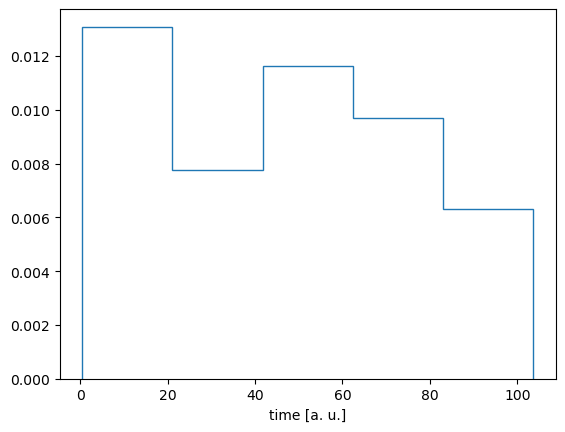

In [44]:
astropy.visualization.hist(t_data, bins="freedman", histtype="step",density=True)
plt.xlabel("time [a. u.]")

Text(0.5, 0, 'flux [a. u.]')

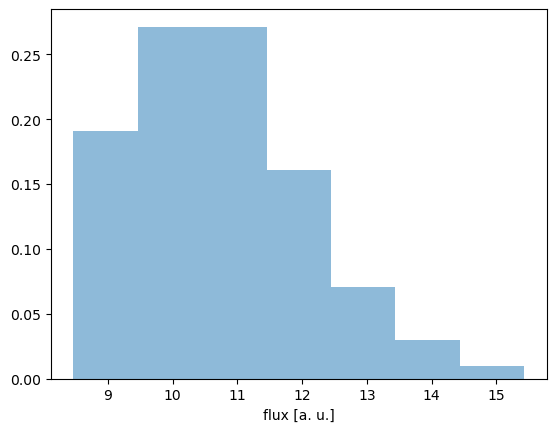

In [53]:
astropy.visualization.hist(flux_data, bins="scott", histtype="bar",density=True, alpha=0.5) #similar to a gaussian 
plt.xlabel("flux [a. u.]")

In [62]:
sigma_flux_data

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

<ErrorbarContainer object of 3 artists>

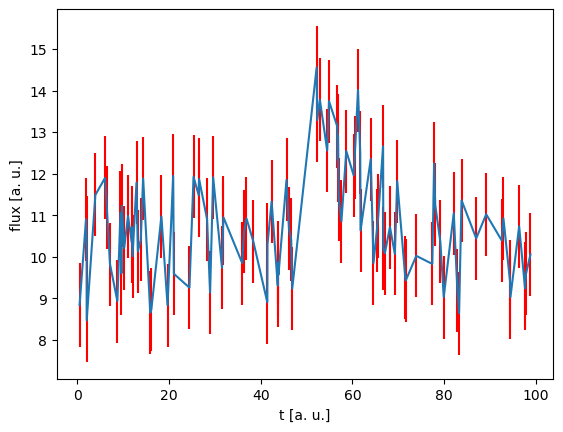

In [48]:
plt.xlabel("t [a. u.]")
plt.ylabel("flux [a. u.]")
plt.errorbar(t_data, flux_data, yerr=sigma_flux_data, xerr=None, ecolor="red")

### model: burst with an exponential tail 

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$ \
where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.


In [65]:
#model to describe data 
#theta rapresents the parameter 
def model(theta,t):
    b, A, alpha, t0 = theta #parameters 
    y = []
    for ti in t:
        if ti < t0:
            y.append(b)
        else:
            y.append(b + A*np.exp(-alpha*(ti-t0)))
    return np.array(y)

#to avoid problem, better to work with log like, log prior and log posterior 
def log_like(theta, sigma_flux, flux, t):
    b, A, alpha, t0 = theta
    analitical_model = model(theta, t)
    return -0.5*np.sum((flux-analitical_model)**2/sigma_flux**2) #chi_square/2

### choose for the prior: 
$$
P(t_0) = \frac{1}{t_{0,max}-t_{0,min}}
$$
$$
P(A) = \frac{1}{A_{max}-A_{min}}
$$
$$
P(b) = \frac{1}{b_{max}-b_{min}}
$$

$$
\log P(\alpha) = -\log \alpha + \text{constant}
$$
the last is because the prior is uniform in $\log(\alpha)$ not in $\alpha$: I need to take into account the factor $\frac{1}{\alpha}$, that doesn't goes to zero when I apply the $\log$. 

In [68]:
#definition of the extreme parameter
t0_min = 0
t0_max = 100
A_min = 0
A_max = 50 
b_min = 0 
b_max = 50 
alpha_min = np.exp(-5)
alpha_max = np.exp(5)

def log_prior(theta): 
    b, A, alpha, t0 = theta
    if (A_min<=A<=A_max) and (b_min<=b<=b_max) and (alpha_min<=alpha<=alpha_max) and (t0_min<=t0<=t0_max): 
        return 0.0 - np.log(alpha)
    else:
        return -np.inf

In [70]:
def log_posterior(theta, sigma_flux, flux, t): 
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return lp+log_like(theta, sigma_flux, flux, t)

print(type(log_like))

<class 'function'>


In [72]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

t0_start=50
A_start=8
b_start=10.4
alpha_start= 0.2

theta_start= [b_start, A_start, alpha_start, t0_start]
# initialize theta 
low = np.array([b_min, A_min, alpha_min, t0_min]) #without array tbe operation isn't possible
high = np.array([b_max, A_max, alpha_max, t0_max])
print(high-low) #i what an idea for the scale of the problem 
#starting_guesses = low + (high - low)*1e-1*np.random.rand(nwalkers, ndim) #what is the more precise way to initialize starting guess
#starting_guesses = theta_start+1e-1*np.random.randn(nwalkers, ndim)
# one can try also with eps*(high-low)*np.random.randn(...)
starting_guesses = theta_start+1e-2*np.random.randn(nwalkers, ndim)

[ 50.          50.         148.40642116 100.        ]


In [74]:
test_val = log_posterior([20,25,1,50], sigma_flux_data, flux_data, t_data)
print(test_val)

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_posterior,args=(sigma_flux_data, flux_data, t_data)) #call a function, in args i don't pass theta
sampler.run_mcmc(starting_guesses, nsteps)

-4426.319023855704


State([[10.37343626 12.27329358  0.20573196 47.6848045 ]
 [10.15617781  7.2928244   0.12458224 47.61127625]
 [10.19695613  4.28917338  0.12900314 51.15454624]
 [10.36317247  7.43671782  0.13808664 47.04090901]
 [10.44714941  7.1486976   0.15500871 48.41883303]
 [10.33197515  7.36246303  0.13681043 47.74560724]
 [10.32999367  8.68827709  0.18598233 47.98338433]
 [10.36925677  4.81635175  0.1288994  50.81173983]
 [10.2787393   5.98038275  0.09690344 47.16301664]
 [10.24468544  9.00712367  0.15842315 48.30999433]
 [10.33263852  6.02950964  0.11763748 47.42622201]
 [10.20098904  7.42573818  0.15615632 49.40544067]
 [10.39777247  4.69766805  0.12153545 47.58971717]
 [10.41031189  6.8285202   0.15024699 49.02602952]
 [10.38846627  5.49766959  0.1524077  51.34940795]
 [10.36884301 11.86983374  0.19566466 47.13552968]
 [10.33917925  4.69397671  0.17372464 52.09533568]
 [10.13723244  7.11743     0.12118849 47.71525667]
 [10.19589732  5.3473204   0.09680882 47.65520438]
 [10.66965306 10.23863299

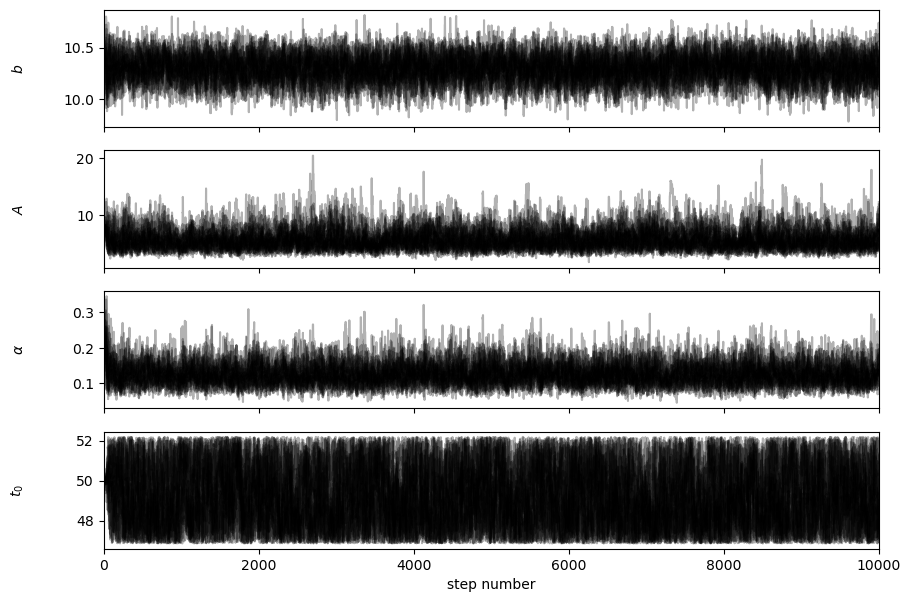

In [76]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = [r"$b$", r"$A$", r"$\alpha$", r"$t_0$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [78]:
tau = sampler.get_autocorr_time() #how many time do I take to have a sample that is independent from the previous one 
print(tau)
#burnin = int(2 * np.max(tau)) #or maybe three, in general watch the parameter you have  

[65.14812938 73.35848134 63.48701984 72.20780115]


In [80]:
#need to discard the burn in point to thin the chain 
flat_samples = sampler.get_chain(discard=150, thin=30, flat=True) 
print(flat_samples.shape)

(6560, 4)


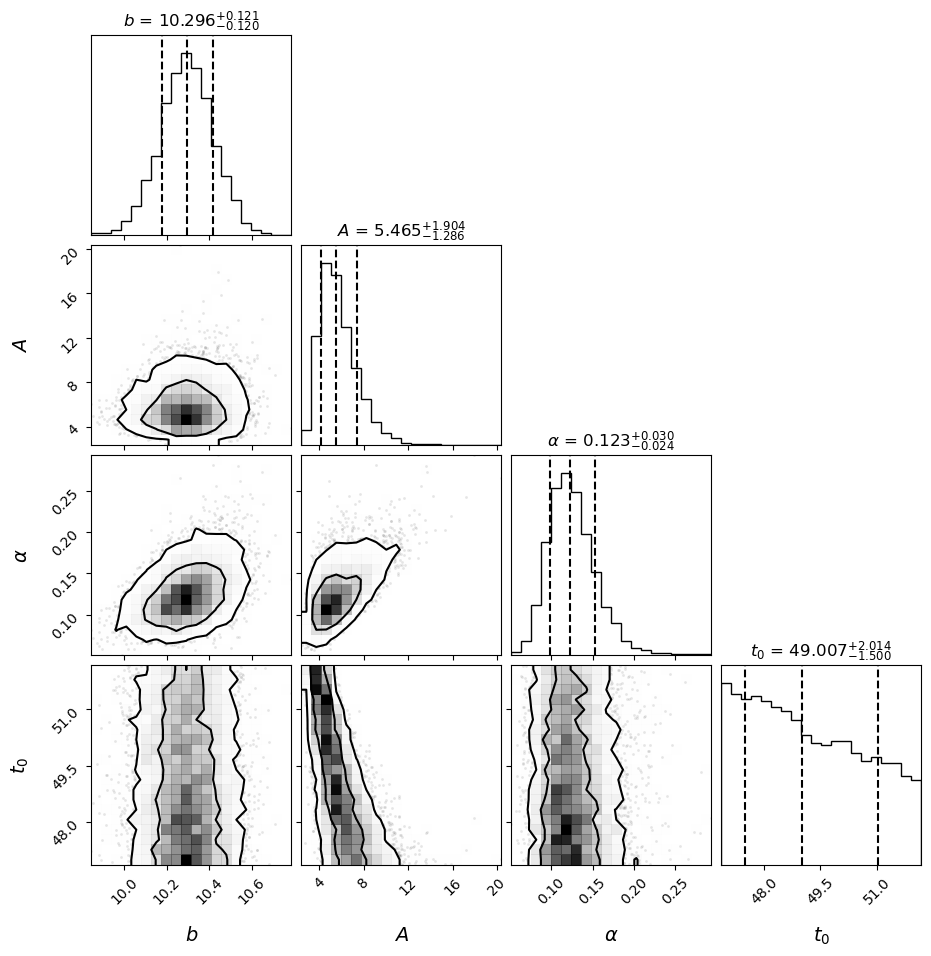

In [82]:
#what is the precision I estimate quantile
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95], #credible level
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

In [84]:
print(flat_samples)

[[10.34745076  5.4000107   0.1736894  50.94041131]
 [10.17969909  4.80666852  0.10374318 51.18730476]
 [10.40115895  5.99128681  0.17471064 49.72864473]
 ...
 [10.09690367  5.33095385  0.09131795 47.50882599]
 [10.29745858  5.28743217  0.0941574  47.47425709]
 [10.56364092  8.39072169  0.18066405 48.79200211]]


In [86]:
sample_from_model = np.random.choice(len(flat_samples), size=100)
samples_100 = flat_samples[sample_from_model]

In [88]:
print(samples_100)

[[10.25337933  6.7130415   0.1353492  49.43111137]
 [10.35366152  3.61146184  0.08788263 50.17963352]
 [10.29250727  4.49418522  0.09954932 51.20869037]
 [10.42379182  5.17844875  0.10428262 47.703688  ]
 [10.31601281  5.80162039  0.14731947 49.73073579]
 [10.33176242  6.07363544  0.10900219 47.22901717]
 [10.25511892  7.35866412  0.13513919 47.07875628]
 [10.37677014  5.96185653  0.10540059 47.41566179]
 [10.27782804  3.51536743  0.08233355 51.32383797]
 [10.18349406  5.73644947  0.09705756 48.2481428 ]
 [10.38513103  4.14957461  0.13863848 51.77843015]
 [10.13190897  7.19735151  0.14971125 48.79486893]
 [10.25136068  5.69824187  0.11320033 48.41643272]
 [10.29681952  6.39122283  0.15267298 48.75246966]
 [10.27994953  6.1592284   0.17371072 49.79711069]
 [10.18353346  4.05933923  0.10573097 51.40012863]
 [10.21541499  3.97578146  0.10362511 51.45511432]
 [10.0745889   6.65381983  0.08815953 47.42033112]
 [10.23520899  6.4123742   0.12289677 48.36022056]
 [10.55443264  3.84113853  0.18

Text(0, 0.5, 'flux [a. u.]')

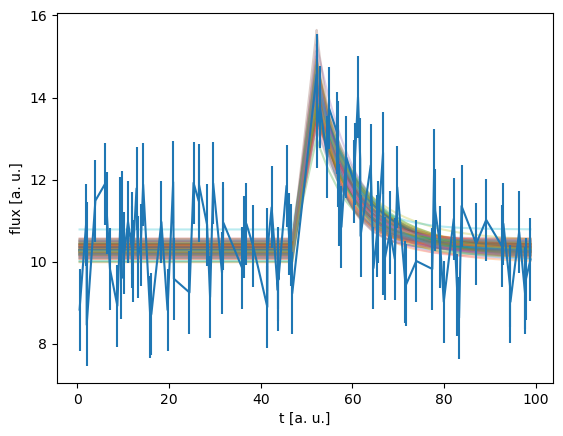

In [94]:
for s in samples_100:
    y = model(s, t_data)
    plt.plot(t_data, y, alpha =0.3)

plt.errorbar(t_data, flux_data, yerr=sigma_flux_data, xerr=None)
plt.xlabel("t [a. u.]")
plt.ylabel("flux [a. u.]")

In [96]:
#end statistic
#labels = [r"$b$", r"$A$", r"$\alpha$", r"$t_0$"]
b_samples = flat_samples[:,0] 
A_samples = flat_samples[:,1]
alpha_samples =  flat_samples[:,2]
t_0_samples = flat_samples[:,3]

b_samples_median = np.median(b_samples)
A_samples_median = np.median(A_samples)
alpha_samples_median = np.median(alpha_samples)
t_0_samples_median = np.median(t_0_samples)

In [98]:
print(b_samples_median)
print(A_samples_median)
print(alpha_samples_median)
print(t_0_samples_median)

10.296076656760924
5.46483850688379
0.12253404372354987
49.00747446921047


In [100]:
#find 90% credible region
p_5_b = np.percentile(flat_samples[:,0],5)
p_95_b = np.percentile(flat_samples[:,0] , 95) 

p_5_A = np.percentile(flat_samples[:,1],5)
p_95_A = np.percentile(flat_samples[:,1] , 95) 

p_5_alpha = np.percentile(flat_samples[:,2],5)
p_95_alpha = np.percentile(flat_samples[:,2] , 95) 

p_5_t0 = np.percentile(flat_samples[:,3],5)
p_95_t0 = np.percentile(flat_samples[:,3] , 95) 

In [102]:
print([p_5_b, b_samples_median, p_95_b])
print([p_5_A, A_samples_median, p_95_A])
print([p_5_alpha, alpha_samples_median, p_95_alpha])
print([p_5_t0, t_0_samples_median, p_95_t0])

[10.089324249832442, 10.296076656760924, 10.497693853960056]
[3.613017318771167, 5.46483850688379, 8.895470586411166]
[0.08550403917000234, 0.12253404372354987, 0.1762082100811575]
[47.06320609181516, 49.00747446921047, 51.795049492148664]


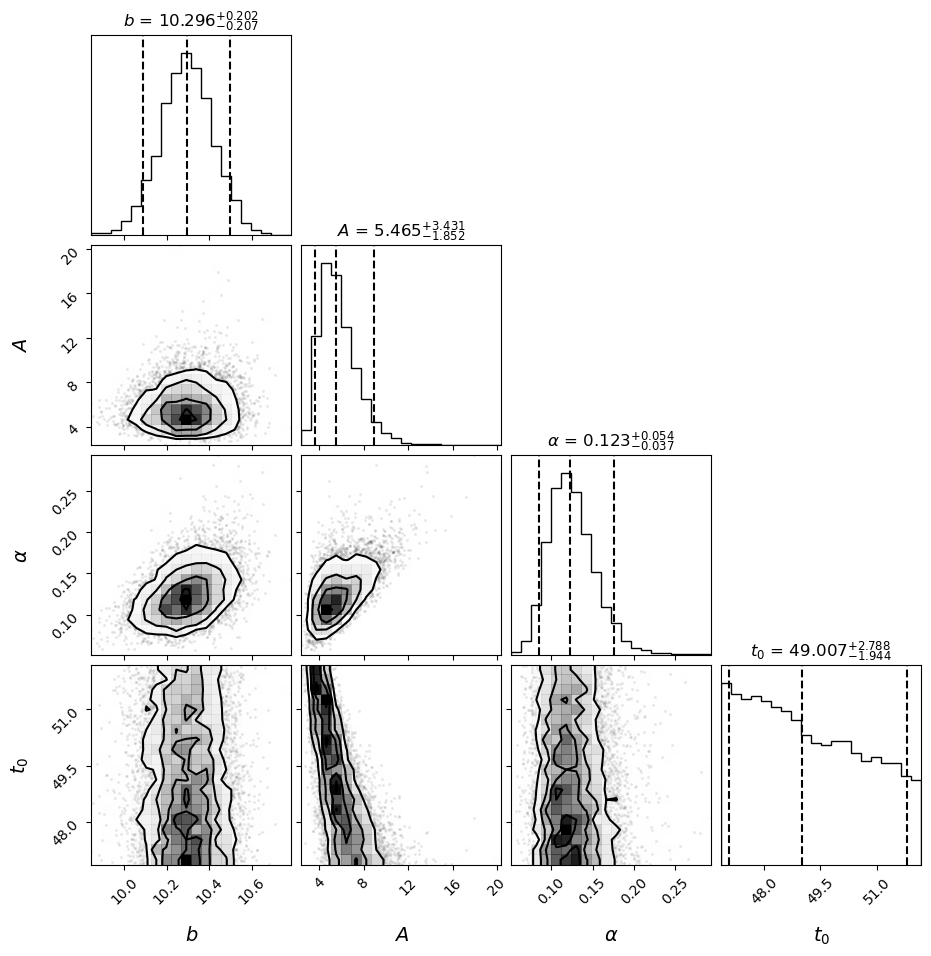

In [104]:
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.05, 0.5, 0.95], #the same as taking the percentile and the median
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)